In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")
# cfe.logger.setLevel("DEBUG")

[2025年04月17日 16时23分48秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
start_id = "Run5_164698952452459"
terminal_states = ["Run5_131097901611291", "Run5_134936662236454", "Run4_200562869397916"]
save_cell_list = [start_id] + terminal_states

fadata = cfe.data.read_bonemarrow() 
fadata

AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'cfe'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

In [ ]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "tsne"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年04月07日 19时56分43秒] INFO     find wrapper type: directed                                                 


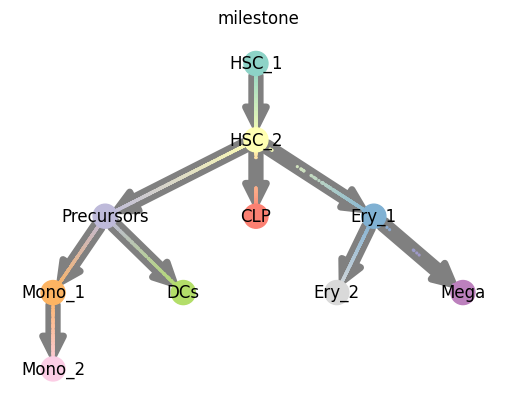

In [ ]:
cfe.plot.plot_wrapper(fadata)

[2025年04月07日 19时57分20秒] INFO     Loaded function: <function cf_palantir at 0x768acf0ac790> from              
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_palantir.py                                                           
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x768ac15c43a0>                                                                   
repreprocess
Sampling and flocking waypoints...
Time for determining waypoints: 0.015025937557220459 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.21151079734166464 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorpt

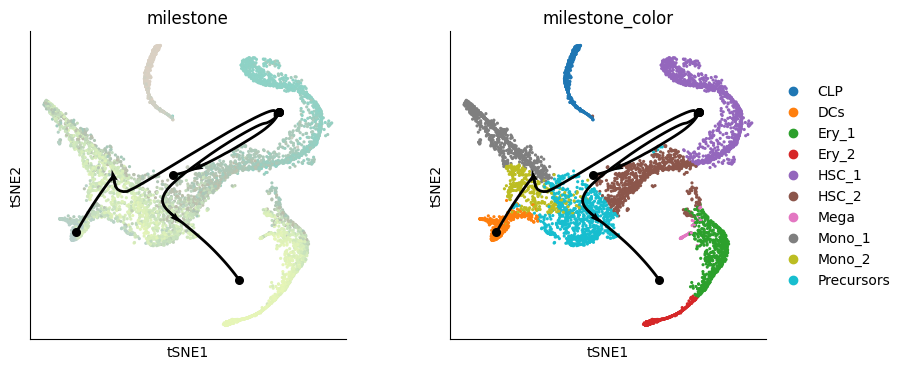

In [ ]:
prior_information = {
    "start_id": start_id,
    "terminal_states": terminal_states,
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
parameters = {"wrapper_type": "probability", "linear_type": "pseudotime"} # add parameters when inferring trajectory


method_name_list = ["palantir"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [ ]:
# 查看里程碑
trajectory_history_dict = fadata.uns["cfe"]["trajectory_history_dict"]
for k in trajectory_history_dict.keys():
    if "palantir" in k:
        print(trajectory_history_dict[k]["milestone_wrapper"]["id_list"])

['milestone_begin', 'Run4_200562869397916', 'Run5_131097901611291', 'Run5_134936662236454']


查看谱系概率